In [118]:
## Important libreries

In [202]:
import pandas as pd
import re
import html
import emoji
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import ast
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from collections import Counter

In [120]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
!pip install emoji

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tuhin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tuhin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\tuhin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Data Loading
### Key Operations:

- Dataset Ingestion: Loads the raw Twitter sentiment data from a CSV file into a Pandas DataFrame.

- Column Normalization: Renames the tweet column to Comment to maintain a consistent naming schema for text processing.

- Integrity Check: Performs an immediate count of null entries within the target column to identify potential gaps in the data.

In [122]:
import pandas as pd

file_path = 'Twitter Sentiments.csv'
df = pd.read_csv(file_path)

df = df.rename(columns={'tweet': 'Comment'})

df.head()
missing_values = df['Comment'].isnull().sum()
print(f"\nMissing entries in 'Comment' column: {missing_values}")


Missing entries in 'Comment' column: 0


In [123]:

def pre_process_noise(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<.*?>', '', text) 
    
    text = emoji.replace_emoji(text, replace='')
    
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    return " ".join(text.split())

df['Cleaned_Comment'] = df['Comment'].apply(pre_process_noise)

In [124]:
df.head()

,id,label,Comment,Cleaned_Comment
0,1,0,@user when a father is dysfunctional and is s...,user when a father is dysfunctional and is so ...
1,2,0,@user @user thanks for #lyft credit i can't us...,user user thanks for lyft credit i can t use c...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,model i love u take with u all the time in ur
4,5,0,factsguide: society now #motivation,factsguide society now motivation


#### Removings coluns 'id','label'

In [126]:
df = df.drop(['id','label'], axis=1)

## Text Preprocessing: Stop Word Removal
### Purpose: This stage focuses on reducing noise in the dataset by filtering out common words that carry little semantic value for sentiment analysis.

Key Operations:

- Vocabulary Definition: Establishes a static set of "stop words" (e.g., "the", "is", "at") that appear frequently but do not contribute to the overall    sentiment of a sentence.

- Tokenization and Filtering: Splits the text into individual words and uses a list comprehension to retain only those that are not present in the         predefined stop word list.

- Case-Insensitive Matching: Converts each word to lowercase during the comparison to ensure words like "The" and "the" are treated equally.

- Feature Engineering: Creates a new column, Comment(after_stop_words), to store the cleaned text while preserving the original data for comparison.

In [128]:
STOP_WORDS = set(["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", 
                  "yourself", "yourselves", "he", "him", "his", "she", "her", "it", "they", "them", 
                  "what", "which", "who", "whom", "this", "that", "am", "is", "are", "was", "were", 
                  "be", "been", "being", "have", "has", "had", "do", "does", "did", "a", "an", "the", 
                  "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", 
                  "with", "about", "against", "into", "through", "before", "after", "to", "from", "up", 
                  "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "here", 
                  "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", 
                  "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", 
                  "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"])

def remove_stopwords(text):
    words = text.split()
    cleaned_words = [word for word in words if word.lower() not in STOP_WORDS]
    return " ".join(cleaned_words)

df['Comment(after_stop_words)'] = df['Cleaned_Comment'].apply(remove_stopwords)

## Text Normalization: Contraction Expansion
#### Purpose: This step expands shortened word forms (e.g., "don't" to "do not") to ensure the NLP model recognizes the full semantic meaning of each word and maintains consistency across the corpus.

Key Operations:

- Mapping Dictionary: Defines a comprehensive lookup table (contraction_map) that pairs common English contractions with their full-form equivalents.

- Regex Pattern Matching: Utilizes the re (Regular Expression) library to create a dynamic search pattern that identifies contractions while respecting    word boundaries (\b).

- Case-Insensitive Replacement: Employs a helper function within the regex sub method to find and replace matches regardless of their original casing.

- Data Integrity: Includes a type-check to handle non-string inputs gracefully, preventing errors during the .apply() process.

In [130]:
contraction_map = {
    "aint": "am not", "arent": "are not", "cant": "cannot", 
    "couldve": "could have", "couldnt": "could not", "didnt": "did not", 
    "doesnt": "does not", "dont": "do not", "hadnt": "had not", 
    "hasnt": "has not", "havent": "have not", "hed": "he would", 
    "hell": "he will", "hes": "he is", "hows": "how is", 
    "id": "i would", "ill": "i will", "im": "i am", "ive": "i have", 
    "isnt": "is not", "itd": "it would", "itll": "it will", "its": "it is", 
    "lets": "let us", "maam": "madam", "mightve": "might have", 
    "oclock": "of the clock", "shed": "she would", "shell": "she will", 
    "shes": "she is", "shouldnt": "should not", "thatd": "that would", 
    "thats": "that is", "theres": "there is", "theyd": "they would", 
    "theyll": "they will", "theyre": "they are", "theyve": "they have", 
    "wasnt": "was not", "wed": "we would", "well": "we will", 
    "were": "we are", "weve": "we have", "werent": "were not", 
    "whats": "what is", "whens": "when is", "wheres": "where is", 
    "wholl": "who will", "whos": "who is", "whys": "why is", 
    "wont": "will not", "wouldve": "would have", "wouldnt": "would not", 
    "yall": "you all", "youd": "you would", "youll": "you will", 
    "youre": "you are", "youve": "you have"
}

def expand_contractions(text):
    if not isinstance(text, str):
        return ""
    
    pattern = re.compile(r'\b(' + '|'.join(re.escape(k) for k in contraction_map.keys()) + r')\b', flags=re.IGNORECASE)
    
    def replace(match):
        return contraction_map[match.group(0).lower()]
    
    return pattern.sub(replace, text)

df['Comment_after_contraction'] = df['Comment(after_stop_words)'].apply(expand_contractions)

print("Contractions Expanded Successfully!")
df.head()

Contractions Expanded Successfully!


,Comment,Cleaned_Comment,Comment(after_stop_words),Comment_after_contraction
0,@user when a father is dysfunctional and is s...,user when a father is dysfunctional and is so ...,user father dysfunctional selfish drags kids d...,user father dysfunctional selfish drags kids d...
1,@user @user thanks for #lyft credit i can't us...,user user thanks for lyft credit i can t use c...,user user thanks lyft credit use cause offer w...,user user thanks lyft credit use cause offer w...
2,bihday your majesty,bihday your majesty,bihday majesty,bihday majesty
3,#model i love u take with u all the time in ...,model i love u take with u all the time in ur,model love u take u time ur,model love u take u time ur
4,factsguide: society now #motivation,factsguide society now motivation,factsguide society motivation,factsguide society motivation


##  Text Refinement and Standardization
### Purpose: This function performs the final "polishing" of the text data, transforming raw strings into a clean, uniform format ready for vectorization or machine learning modeling.

Key Operations:

- Case Normalization: Converts all characters to lowercase to ensure the model treats "Excellent" and "excellent" as the same token.

- Character Sequence Reduction: Uses regex ((.)\1{2,}) to truncate elongated words (e.g., changing "looooove" to "loove"), which helps in reducing         vocabulary noise while preserving some intensity.

- Non-Alphabetic Filtering: Strips out special characters, numbers, and punctuation, retaining only lowercase English letters (a-z) and whitespace.

- Whitespace Normalization: Employs a split() and join() maneuver to remove redundant internal spaces and leading/trailing trim, ensuring a clean string   structure.

In [132]:
def final_clean(text):
    # 1. Lowercase
    text = text.lower() 
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = " ".join(text.split())
    return text

df['polished_column'] = df['Comment_after_contraction'].apply(final_clean)

In [133]:
df.head()

,Comment,Cleaned_Comment,Comment(after_stop_words),Comment_after_contraction,polished_column
0,@user when a father is dysfunctional and is s...,user when a father is dysfunctional and is so ...,user father dysfunctional selfish drags kids d...,user father dysfunctional selfish drags kids d...,user father dysfunctional selfish drags kids d...
1,@user @user thanks for #lyft credit i can't us...,user user thanks for lyft credit i can t use c...,user user thanks lyft credit use cause offer w...,user user thanks lyft credit use cause offer w...,user user thanks lyft credit use cause offer w...
2,bihday your majesty,bihday your majesty,bihday majesty,bihday majesty,bihday majesty
3,#model i love u take with u all the time in ...,model i love u take with u all the time in ur,model love u take u time ur,model love u take u time ur,model love u take u time ur
4,factsguide: society now #motivation,factsguide society now motivation,factsguide society motivation,factsguide society motivation,factsguide society motivation


## Secondary Noise Reduction and Domain-Specific Filtering
### Purpose: This refined cleaning pass targets domain-specific noise (like platform-specific handles) and removes lingering short-form tokens that do not contribute to sentiment or topical meaning.

Key Operations:

- Domain-Specific Filtering: Uses a regex pattern to identify and remove the specific term "user," which often appears as a placeholder in anonymized      Twitter datasets.

- Stop Word Re-filtering: Ensures that even after case conversion and character reduction from previous steps, no common stop words remain in the corpus.

- Short Token Removal: Filters out any remaining single-character words (e.g., "a", "x", "s") using a length constraint (len(w) > 1), which effectively    cleans up fragmented text or leftover punctuation debris.

- Redundancy Protection: Includes an isinstance check to handle any unexpected null or non-string values that might have been introduced during previous   transformations.

In [135]:
STOP_WORDS = set([
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", 
    "yourself", "yourselves", "he", "him", "his", "she", "her", "it", "they", "them", 
    "what", "which", "who", "whom", "this", "that", "am", "is", "are", "was", "were", 
    "be", "been", "being", "have", "has", "had", "do", "does", "did", "a", "an", "the", 
    "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", 
    "with", "about", "against", "into", "through", "before", "after", "to", "from", "up", 
    "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "here", 
    "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", 
    "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", 
    "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now",
    "amp", "rt" 
])

def clean_user_and_stopwords(text):
    if not isinstance(text, str):
        return ""
    
    # Remove 'user'
    text = re.sub(r'\buser\b', '', text.lower())
    
    words = text.split()
    # Change len(w) > 1 to len(w) > 2 to remove 'ur', 're', 've', etc.
    cleaned_words = [w for w in words if w not in STOP_WORDS and len(w) > 2]
    
    return " ".join(cleaned_words)

df['polished_column'] = df['polished_column'].apply(clean_user_and_stopwords)


## Text Tokenization: Breaking Sentences into Atomic Units
### Purpose: This step transforms the cleaned text strings into discrete lists of words (tokens). This is a fundamental requirement for most Natural Language Processing (NLP) tasks, as it allows the model to analyze the frequency and relationship of individual words rather than processing the sentence as a single block.


In [137]:
df['Tokenized_Comment'] = df['polished_column'].apply(word_tokenize)

In [138]:
df[['polished_column', 'Tokenized_Comment']].head()

,polished_column,Tokenized_Comment
0,father dysfunctional selfish drags kids dysfun...,"[father, dysfunctional, selfish, drags, kids, ..."
1,thanks lyft credit use cause offer wheelchair ...,"[thanks, lyft, credit, use, cause, offer, whee..."
2,bihday majesty,"[bihday, majesty]"
3,model love take time,"[model, love, take, time]"
4,factsguide society motivation,"[factsguide, society, motivation]"


### Lemmatization and Final Token Cleaning

In this step, the tokenized comments are further refined using **WordNet Lemmatization** to convert words into their base or dictionary form.  
The function also corrects a common slang spelling error (`bihday → birthday`) and filters out unwanted tokens such as `'na'`, `'ta'`, and very short words.  
Additionally, it ensures that the input is properly handled as a list of tokens before processing.  
The cleaned and normalized tokens are then stored in a new column called **`Lemmatized`** for downstream NLP analysis or modeling.

In [177]:
lemmatizer = WordNetLemmatizer()

def final_polish_tokens(token_list):
    if isinstance(token_list, str):
        token_list = ast.literal_eval(token_list)
        
    if not isinstance(token_list, list):
        return []
    
    clean_list = []
    for token in token_list:
        # Fix the most common slang error
        if token == 'bihday':
            token = 'birthday'
        
        # Proper Lemmatization
        lemma = lemmatizer.lemmatize(token)
        
        # Filter 'na', 'ta' and short tokens
        if lemma not in ['na', 'ta'] and len(lemma) > 2:
            clean_list.append(lemma)
            
    return clean_list
df['Lemmatized'] = df['Tokenized_Comment'].apply(final_polish_tokens)

In [181]:
print(df[['Tokenized_Comment', 'Lemmatized']].head())

                                   Tokenized_Comment  \
0  [father, dysfunctional, selfish, drag, kid, dy...   
1  [thanks, lyft, credit, use, cause, offer, whee...   
2                                [birthday, majesty]   
3                          [model, love, take, time]   
4                  [factsguide, society, motivation]   

                                          Lemmatized  
0  [father, dysfunctional, selfish, drag, kid, dy...  
1  [thanks, lyft, credit, use, cause, offer, whee...  
2                                [birthday, majesty]  
3                          [model, love, take, time]  
4                  [factsguide, society, motivation]  


In [185]:
df.head()

,Comment,Cleaned_Comment,Comment(after_stop_words),Comment_after_contraction,polished_column,Tokenized_Comment,success_flag,Lemmatized
0,@user when a father is dysfunctional and is s...,user when a father is dysfunctional and is so ...,user father dysfunctional selfish drags kids d...,user father dysfunctional selfish drags kids d...,father dysfunctional selfish drags kids dysfun...,"[father, dysfunctional, selfish, drag, kid, dy...",1,"[father, dysfunctional, selfish, drag, kid, dy..."
1,@user @user thanks for #lyft credit i can't us...,user user thanks for lyft credit i can t use c...,user user thanks lyft credit use cause offer w...,user user thanks lyft credit use cause offer w...,thanks lyft credit use cause offer wheelchair ...,"[thanks, lyft, credit, use, cause, offer, whee...",1,"[thanks, lyft, credit, use, cause, offer, whee..."
2,bihday your majesty,bihday your majesty,bihday majesty,bihday majesty,bihday majesty,"[birthday, majesty]",1,"[birthday, majesty]"
3,#model i love u take with u all the time in ...,model i love u take with u all the time in ur,model love u take u time ur,model love u take u time ur,model love take time,"[model, love, take, time]",1,"[model, love, take, time]"
4,factsguide: society now #motivation,factsguide society now motivation,factsguide society motivation,factsguide society motivation,factsguide society motivation,"[factsguide, society, motivation]",1,"[factsguide, society, motivation]"


## Data Cleaning Validation and Metrics
#### Purpose: This step quantifies the impact of the preprocessing pipeline by comparing the original word counts against the final token counts. It serves as a quality control measure to identify rows that may have been completely filtered out.

Key Operations:

- Baseline Measurement: Calculates word_count_before by splitting the raw text, providing a reference point for the original message length.

- Post-Processing Metric: Measures the length of the lammetized list to determine how many substantive tokens remain after noise removal and               lemmatization.

- Cleaning Status Flagging: Categorizes each entry as "Success" or "Filtered/Empty." This helps identify tweets that consisted entirely of stop words,     URLs, or noise, which might need to be handled specifically before model training.

- Feature Engineering: Adds these diagnostic metrics to the df_final DataFrame for easy auditing of the cleaning efficiency.

In [196]:
df_final = df[['Comment', 'Lemmatized']].copy()
df_final['word_count_before'] = df['Comment'].apply(lambda x: len(str(x).split()))
df_final['word_count_after'] = df['Lemmatized'].apply(lambda x: len(x))
df_final['cleaning_status'] = df_final['word_count_after'].apply(lambda x: 'Success' if x > 0 else 'Filtered/Empty')

In [198]:
df_final.head()

,Comment,Lemmatized,word_count_before,word_count_after,cleaning_status
0,@user when a father is dysfunctional and is s...,"[father, dysfunctional, selfish, drag, kid, dy...",18,7,Success
1,@user @user thanks for #lyft credit i can't us...,"[thanks, lyft, credit, use, cause, offer, whee...",19,11,Success
2,bihday your majesty,"[birthday, majesty]",3,2,Success
3,#model i love u take with u all the time in ...,"[model, love, take, time]",14,4,Success
4,factsguide: society now #motivation,"[factsguide, society, motivation]",4,3,Success


### Word Frequency Analysis and Visualization

In this step, the lemmatized tokens are prepared for analysis by ensuring that each entry in the `Lemmatized` column is in list format. All tokens are then combined into a single list to analyze overall word usage across the dataset. The `Counter` class is used to identify the **top 15 most frequent words**. Finally, a **bar chart visualization** is created using Matplotlib to clearly display the frequency distribution of the most common words in the cleaned text data.

Top 15 Most Common Words:
day: 2924
love: 2875
happy: 1707
life: 1268
time: 1262
like: 1222
today: 1106
get: 1003
new: 1003
father: 957
thankful: 952
positive: 938
people: 894
good: 882
birthday: 874


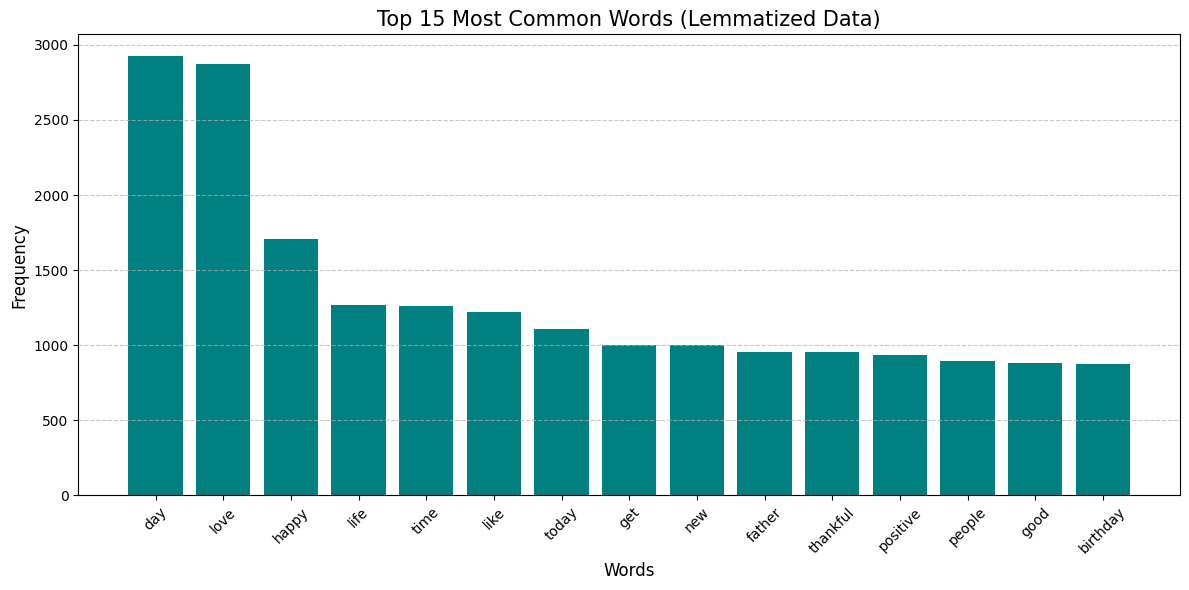

In [204]:
df_final['Lemmatized'] = df_final['Lemmatized'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 3. Combine all words into one giant list
all_words = [word for sublist in df_final['Lemmatized'] for word in sublist]

# 4. Find the top 15 most common words
top_15 = Counter(all_words).most_common(15)

# 5. Print the results to your console
print("Top 15 Most Common Words:")
for word, count in top_15:
    print(f"{word}: {count}")

# 6. Create a Bar Chart Visualization
words, counts = zip(*top_15)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='teal')
plt.title('Top 15 Most Common Words (Lemmatized Data)', fontsize=15)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sentiment-Based Word Categorization and Visualization

In this step, the lemmatized token lists are first converted back into Python lists using `ast.literal_eval` to ensure proper processing. All tokens are then aggregated and their frequencies are calculated using `Counter`. Each word is analyzed with **TextBlob sentiment polarity** to classify it as either positive or negative. Finally, the top 15 most frequent positive and negative words are visualized using **side-by-side horizontal bar charts** for easier comparison of sentiment patterns in the dataset.

Analyzing sentiment of unique words...


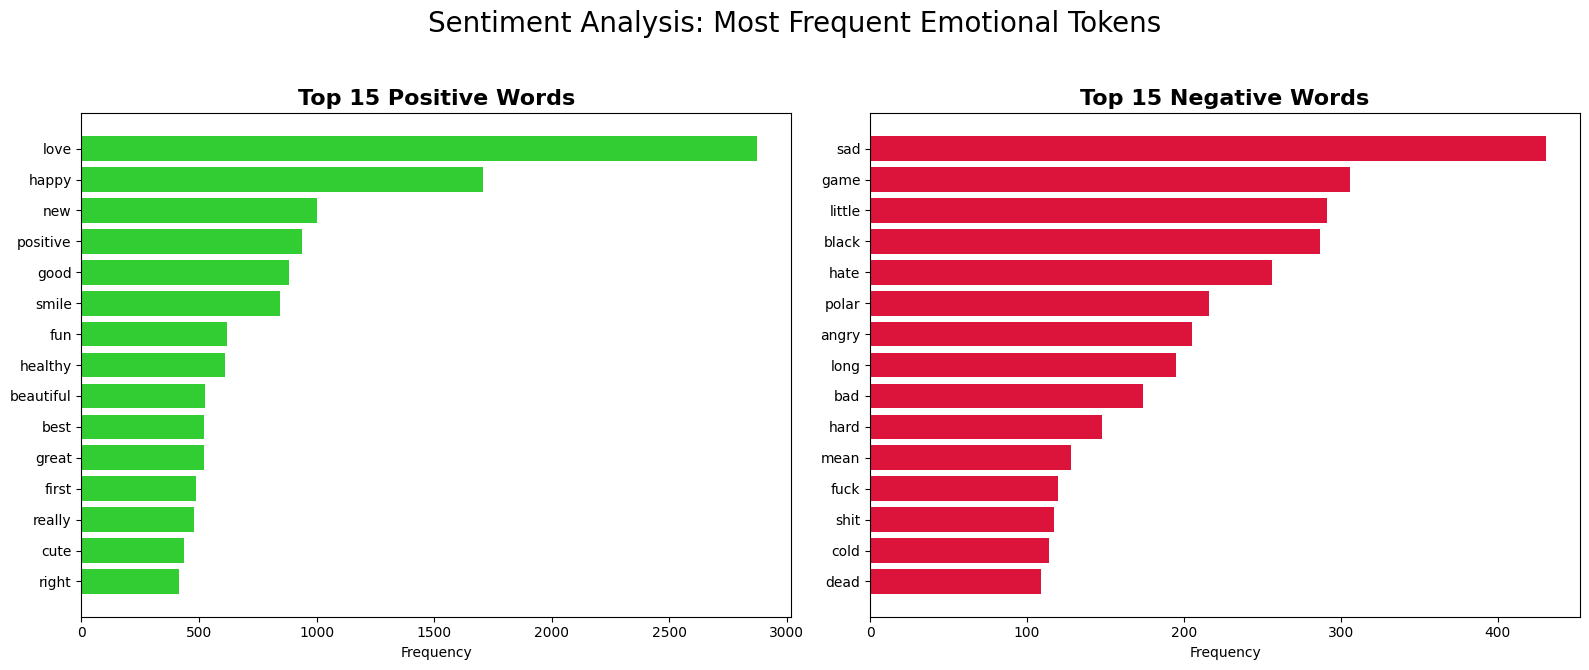

--- Analysis Complete ---
Total Positive Tokens Found: 446
Total Negative Tokens Found: 413


In [216]:
 df_final['Lemmatized'] = df_final['Lemmatized'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 3. Get all unique words and their frequencies
all_words = [word for sublist in df_final['Lemmatized'] for word in sublist]
word_counts = Counter(all_words)

pos_words = []
neg_words = []

# 4. Categorize words using TextBlob Polarity
print("Analyzing sentiment of unique words...")
for word, count in word_counts.items():
    score = TextBlob(word).sentiment.polarity
    if score > 0:
        pos_words.append((word, count))
    elif score < 0:
        neg_words.append((word, count))

# 5. Sort and get top 15 for each category
top_pos = sorted(pos_words, key=lambda x: x[1], reverse=True)[:15]
top_neg = sorted(neg_words, key=lambda x: x[1], reverse=True)[:15]

# 6. Visualization: Side-by-Side Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Positive Chart (Left)
p_words, p_counts = zip(*top_pos)
ax1.barh(p_words, p_counts, color='limegreen')
ax1.set_title('Top 15 Positive Words', fontsize=16, fontweight='bold')
ax1.set_xlabel('Frequency')
ax1.invert_yaxis() 

# Negative Chart (Right)
n_words, n_counts = zip(*top_neg)
ax2.barh(n_words, n_counts, color='crimson')
ax2.set_title('Top 15 Negative Words', fontsize=16, fontweight='bold')
ax2.set_xlabel('Frequency')
ax2.invert_yaxis()

plt.suptitle('Sentiment Analysis: Most Frequent Emotional Tokens', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("--- Analysis Complete ---")
print(f"Total Positive Tokens Found: {len(pos_words)}")
print(f"Total Negative Tokens Found: {len(neg_words)}")